In [6]:
import pandas as pd
df = pd.read_csv('track-c-life-support-hre/mars500_eclss_scaled_100p_730d.csv')

In [7]:
df

,day,sol,crew_size,activity_level,dust_storm_flag,solar_availability,o2_consumption_kg,co2_production_kg,water_use_kg,food_kg,waste_kg,o2_recovery_efficiency,water_recovery_efficiency,net_o2_makeup_kg,net_water_makeup_kg,greenhouse_ventilation_m3_per_h,cabin_co2_ppm_proxy
0,0,0,100,1.15,0,0.906,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,926
1,1,1,100,1.15,0,0.917,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,881
2,2,2,100,1.15,0,0.986,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,888
3,3,3,100,1.15,0,0.872,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,930
4,4,4,100,1.15,0,0.835,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,725,725,100,1.15,0,0.904,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,908
726,726,726,100,0.90,0,0.933,75.6,90.0,332.5,183.0,10.8,0.92,0.95,6.05,16.63,1980.0,821
727,727,727,100,0.90,0,0.939,75.6,90.0,332.5,183.0,10.8,0.92,0.95,6.05,16.63,1980.0,818
728,728,728,100,1.15,0,0.810,96.6,115.0,367.5,183.0,13.8,0.92,0.95,7.73,18.38,1980.0,895


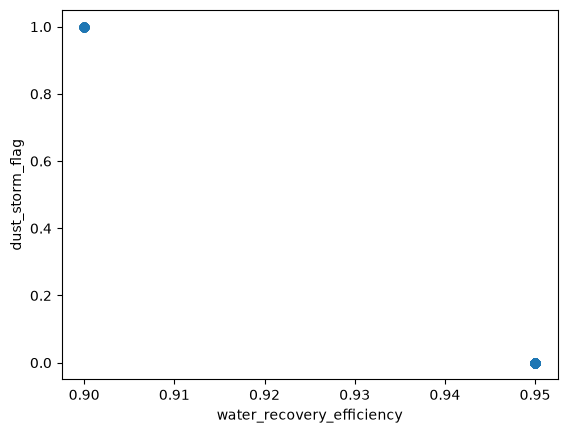

In [28]:
df["future_min_solar_5d"] = (
    df["solar_availability"]
      .shift(-1)
      .rolling(5)
      .min()
)

df["low_solar_5d"] = (
    df["future_min_solar_5d"] < 0.3
).astype(int)

features = [
    "solar_availability",
    "dust_storm_flag",
    "activity_level",
    "o2_recovery_efficiency",
    "water_recovery_efficiency",
    "greenhouse_ventilation_m3_per_h",
    "cabin_co2_ppm_proxy",
]

df["solar_lag_1"] = df["solar_availability"].shift(1)
df["solar_lag_3"] = df["solar_availability"].shift(3)
df["solar_lag_7"] = df["solar_availability"].shift(7)

df["solar_mean_3d"] = df["solar_availability"].rolling(3).mean()
df["solar_mean_7d"] = df["solar_availability"].rolling(7).mean()
df["solar_std_7d"] = df["solar_availability"].rolling(7).std()

<Axes: xlabel='dust_storm_flag'>

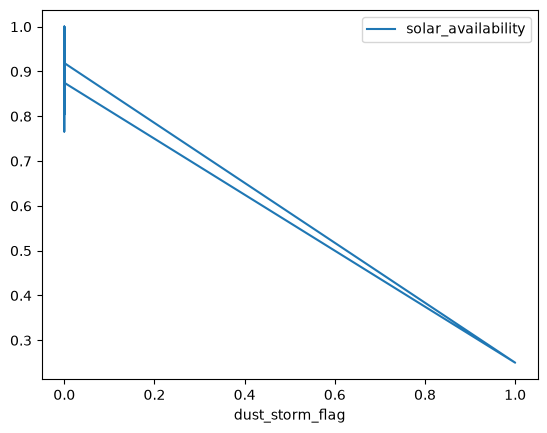

In [18]:
df.plot(x,y,kind='line')